In [1]:
import logging
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np
import pandas as pd
import os

logging.basicConfig(level=logging.INFO)

In [2]:
%load_ext autoreload
%autoreload 2

/home/nafiseh/GitHub/timeseries-research/.venv/lib/python3.11/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
INFO:datasets:JAX version 0.7.1 available.
INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/tmp_results/SimpleTime_Multivariate_Full_20260210-182805/Chronos2-Multivariate
INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/simpletime/datasets_10

INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


Evaluating Datasets:   0%|          | 0/2 [00:00<?, ?it/s]

10it [00:00, 713.83it/s]
INFO:ts_toolkit.pipeline.eval:Results for univariate/growing_sine have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/SimpleTime_Multivariate_Full_20260210-182805/Chronos2-Multivariate/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/SimpleTime_Multivariate_Full_20260210-182805/Chronos2-Multivariate/SimpleTime_Multivariate_Full_20260210-182805_config.yaml


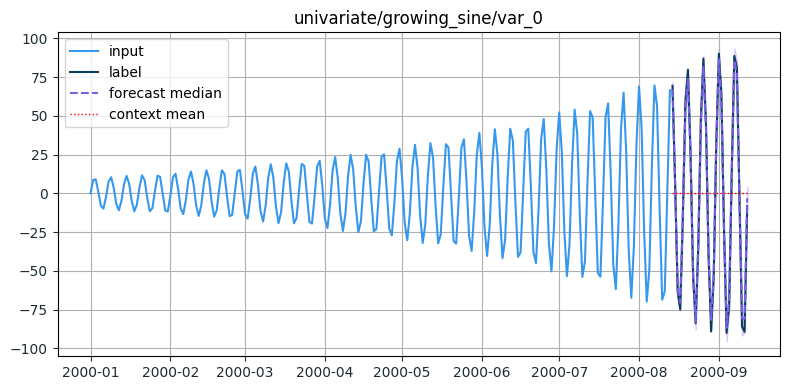

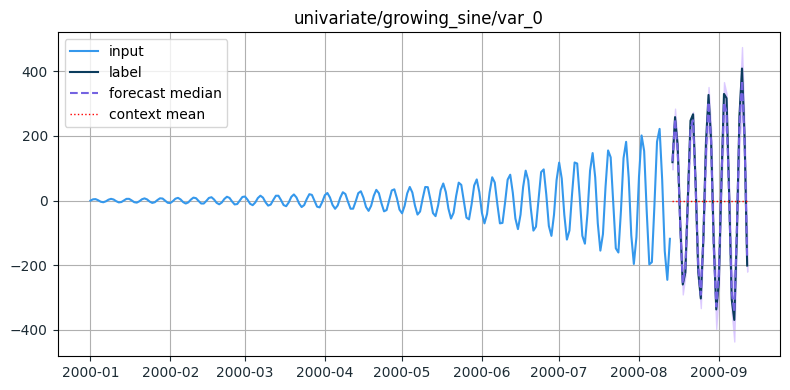

10it [00:00, 682.69it/s]
INFO:ts_toolkit.pipeline.eval:Results for multivariate_lagged/random_walk have been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/SimpleTime_Multivariate_Full_20260210-182805/Chronos2-Multivariate/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/nafiseh/GitHub/timeseries-research/tmp_results/SimpleTime_Multivariate_Full_20260210-182805/Chronos2-Multivariate/SimpleTime_Multivariate_Full_20260210-182805_config.yaml
/home/nafiseh/GitHub/timeseries-research/src/ts_toolkit/pipeline/visualization.py:144: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


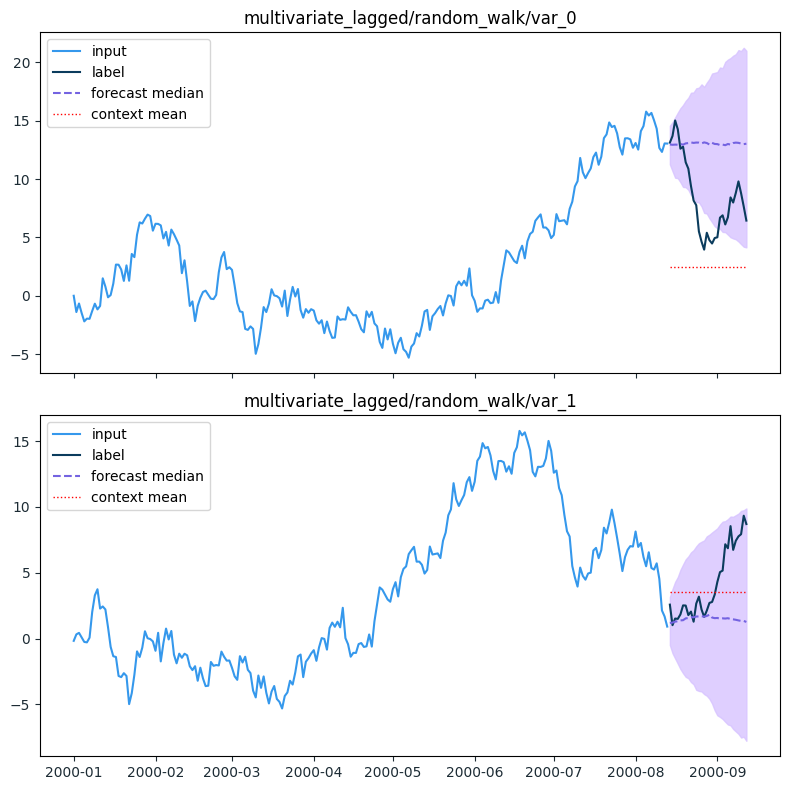

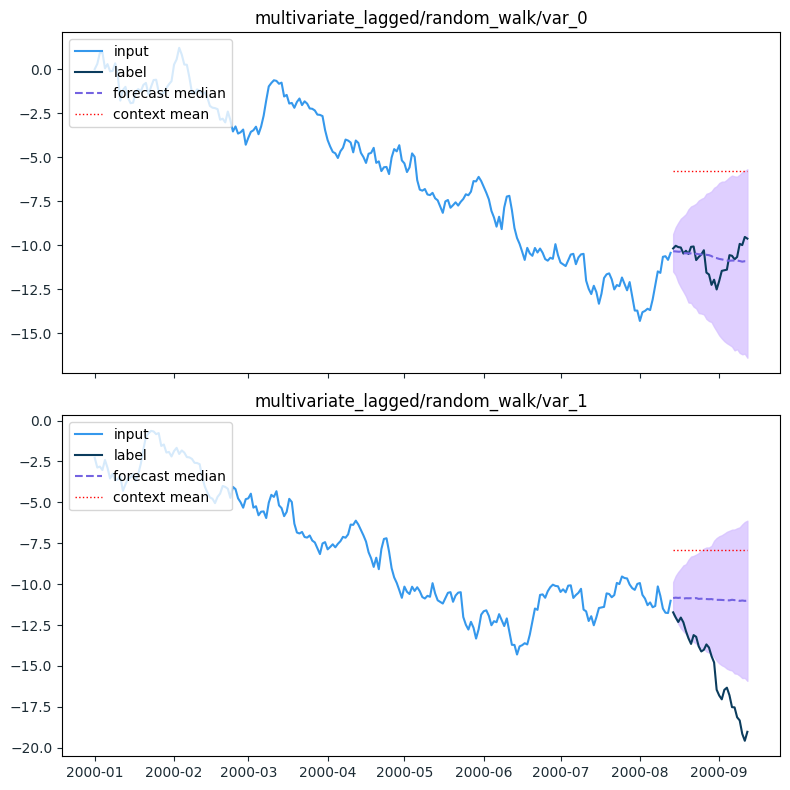

INFO:ts_toolkit.pipeline.runner:
--- ✅ All evaluations complete. ---


,dataset,variate,num_variates,model,eval_metrics/MeanAttractionRatio[0.5][512],eval_metrics/MeanBiasRatio[0.5][512],eval_metrics/PathVolatilityRatio[0.5][512],eval_metrics/PersistenceSkillRatio[0.5],eval_metrics/MeanSkillRatio[0.5][512],eval_metrics/NormalizedMeanBias[0.5],...,eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss
0,univariate/growing_sine/short,MULTI,1,Chronos2-Multivariate,1.084115,0.816667,1.081090,0.077419,0.090308,-0.004459,...,401.095068,12.132572,0.683241,0.218984,0.166404,4.083241,20.027358,0.149146,0.090353,0.067233
0,multivariate_lagged/random_walk/short,MULTI,2,Chronos2-Multivariate,0.942979,0.590000,16.059855,0.956279,0.371379,-0.085034,...,5.011371,1.409387,3.236435,1.470343,0.542284,21.014082,2.238609,0.348866,0.219640,0.168404


In [3]:
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config

# --- Load configuration ---
# config_path = "./configs/experiments/simpleTSbench.yaml"
# config_path = "./configs/experiments/simpletime_sample.yaml"
# config_path = "./configs/experiments/gifteval_sample.yaml"
# config_path = "./configs/experiments/gifteval.yaml"
# config_path = "./configs/experiments/real.yaml"

model_repertoire = {
    "Moirai": {"name": "Moirai", "params": {"repo_id": "Salesforce/moirai-1.1-R-large", "batch_size": 64}},
    "Sundial": {"name": "Sundial", "params": { "batch_size": 64}},
    "Toto": {"name": "Toto", "params": {"context_length": 4_096, "batch_size": 64}},
    "Chronos2": {"name": "Chronos2", "params": { "batch_size": 64}}
}
model_name = "Chronos2" # "Sundial" # "Toto" # "Chronos2"
multivariate = True
multivariate_str = "Multivariate" if multivariate else "Univariate"

config_dict = {
    "experiment_name": f"SimpleTime_{multivariate_str}_Full",

    "paths": {
        "storage_path": "data/simpletime/datasets_10",
        "output_path": "tmp_results"
    },
    "forecaster": {
        "name": "MedianEnsemble",
        "max_length": 512,
        "models": [model_repertoire[model_name]],
        "alias": f"{model_name}-{multivariate_str}" # An identifier for your ensemble
    },
    "evaluation": {
        "to_univariate": not multivariate,
        "show_plot": True,
        "eval_substr": "dim0"
    },
    "datasets": [
        {'name': 'univariate/growing_sine', 'term': 'short'}, 
        {'name': 'multivariate_lagged/random_walk', 'term': 'short'}, 
    ]
}

config = load_config(config_dict=config_dict) # config_path

# --- Set up the evaluation pipeline ---
pipeline = TsPipeline(config)
# print(pipeline.get_forecast_horizons())
pipeline.run(skip_existing=False, num_plots=2)
pipeline.get_results()


In [4]:
pipeline.evaluator.target_dim

2

## Run Chronos2 Finetuned Models

In [5]:
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config

multivariate = True
multivariate_str = "Multivariate" if multivariate else "Univariate"
model_list = [
    {
        "repo_id": "results/finetuned_models/chronos2/20260128_132214/finetuned-ckpt",
        "alias": f"Chronos2-FineTuned-1M-Random-{multivariate_str}-SimpleTSbench-1ksteps"
    },
    {
        "repo_id": "results/finetuned_models/chronos2/20260124_131241/checkpoint-164500",
        "alias": f"Chronos2-FineTuned-1M-Random-{multivariate_str}-SimpleTSbench-164ksteps"
    },
    {
        "repo_id": "results/finetuned_models/chronos2/20260129_154111/finetuned-ckpt",
        "alias": f"Chronos2-FineTuned-1M-Random-{multivariate_str}-SimpleTSbench-100ksteps"
    }
]

model_idx = 2
config_dict = {
    "experiment_name": f"simpleTSbench_{multivariate_str}_Finetuned_Full",

    "paths": {
        "storage_path": "data/simpleTSbench/datasets_1k",
        "output_path": "results"
    },
    "forecaster": {
        "name": "MedianEnsemble",
        "max_length": 512,
        "models": [
            {
                "name": "Chronos2",
                "params": {
                    "repo_id": model_list[model_idx]['repo_id'],
                    "batch_size": 64
                },
            }
        ],
        "alias": model_list[model_idx]["alias"] # An identifier for your ensemble
    },
    "evaluation": {
        "to_univariate": not multivariate,
        "show_plot": False,
        "eval_substr": "dim0"
    }
}
  
  
config = load_config(config_dict=config_dict)
# --- Set up the evaluation pipeline ---
pipeline = TsPipeline(config)
pipeline.run(skip_existing=False, num_plots=1)

pipeline.get_results()


INFO:ts_toolkit.pipeline.runner:No datasets specified in config.datasets. Discovering datasets from: /home/nafiseh/GitHub/timeseries-research/data/simpleTSbench/datasets_1k
INFO:ts_toolkit.pipeline.runner:Warning: storage_path '/home/nafiseh/GitHub/timeseries-research/data/simpleTSbench/datasets_1k' does not exist or is not a directory.
INFO:ts_toolkit.pipeline.runner:   - Results will be saved to: /home/nafiseh/GitHub/timeseries-research/results/simpleTSbench_Multivariate_Finetuned_Full_20260210-182809/Chronos2-FineTuned-1M-Random-Multivariate-SimpleTSbench-100ksteps


INFO:ts_toolkit.pipeline.runner:   - Datasets will be loaded from: /home/nafiseh/GitHub/timeseries-research/data/simpleTSbench/datasets_1k

INFO:ts_toolkit.pipeline.runner:
--- Starting Evaluation ---


Evaluating Datasets: 0it [00:00, ?it/s]

INFO:ts_toolkit.pipeline.runner:
--- ✅ All evaluations complete. ---


AttributeError: 'TsPipeline' object has no attribute 'results_df'

In [ ]:
import pandas as pd
path = "results"
metric = "MASE"
df_results_multi = pd.read_csv(f"{path}/simpleTSbench_Full_20260128-132415/Chronos2-Multivariate-Full-SimpleTSBench/all_results.csv")
df_results_uni = pd.read_csv(f"{path}/simpleTSbench_Full_20260128-134518/Chronos2-Univariate-Full-SimpleTSBench/all_results.csv")

df_results = pd.concat([df_results_multi, df_results_uni], ignore_index=True)
# display(df_results)
# Filter the required columns
df_mase = df_results.pivot_table(
    index=['dataset', 'num_variates'], 
    columns='variate', 
    values=f'eval_metrics/{metric}[0.5]'
)
df_mase['multi_improv%'] = (df_mase['UNI'] - df_mase['MULTI'])/df_mase['UNI'] * 100
# Display the MASE column side by side for MULTI and UNI
df_mase = df_mase[['MULTI', 'UNI', 'multi_improv%']].sort_values(['multi_improv%'], ascending=False)
display(df_mase.round(2))

In [ ]:
path = "results"
dataset_1 = 'Chronos2-Multivariate-Full-SimpleTSBench'
 # 'Chronos2-FineTuned-Multivariate-SimpleTSBench'
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-133100/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-4, num_steps=1000, prediction_length=48, batch_size=32
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-134148/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=1000, prediction_length=48, batch_size=32
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-134827/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=500, prediction_length=48, batch_size=32
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-135039/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=100, prediction_length=48, batch_size=32
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-140840/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=20, prediction_length=48, batch_size=32
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-141435/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=10, prediction_length=48, batch_size=32
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-143536/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=10, prediction_length=48, batch_size=64
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251209-143536/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=10, prediction_length=48, batch_size=64
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251216-141345/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=10, prediction_length=48, batch_size=64 new dataset w/ 48 lag
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20251216-141732/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=50, prediction_length=48, batch_size=64 new dataset w/ 48 lag
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Full_20260108-165001/Chronos2-FineTuned-Multivariate-SimpleTSBench/all_results.csv") # lr=1e-5, num_steps=50, prediction_length=48, batch_size=64 new dataset w/ 48 lag

# dataset_2 = 'Chronos2-FineTuned-1M-Random-Multivariate-Lagged-SimpleTSbench-1ksteps'
# df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Fintuned_Full_20260128-135918/{dataset_2}/all_results.csv") # lr=1e-4, num_step=100kk, prediction_length=48, batch_size=64 1M dataset w/ 48 lag finetuned on ["multivariate_lagged"], ["exponential", "noise_patch", "normal", "poisson", "random_walk"]

dataset_2 = 'Chronos2-FineTuned-1M-Random-Multivariate-Lagged-SimpleTSbench-100ksteps' # 'Chronos2-FineTuned-1M-Random-Multivariate-Lagged-SimpleTSbench-164ksteps'
dataset_2_folder = '20260202-094704/' # '20260128-151144'
df_results_finetuned = pd.read_csv(f"{path}/simpleTSbench_Fintuned_Full_{dataset_2_folder}/{dataset_2}/all_results.csv") # lr=1e-4, num_step=100kk, prediction_length=48, batch_size=64 1M dataset w/ 48 lag finetuned on ["multivariate_lagged"], ["exponential", "noise_patch", "normal", "poisson", "random_walk"]


df_results = pd.concat([df_results_multi, df_results_finetuned], ignore_index=True)
# display(df_results)
# Filter the required columns
metric = "MASE"
df_mase = df_results.pivot_table(
    index=['dataset', 'num_variates'], 
    columns='model', 
    values=f'eval_metrics/{metric}[0.5]'
)
df_mase['finetune_improv%'] = (df_mase[dataset_1] - df_mase[dataset_2])/df_mase[dataset_1] * 100
# # Display the MASE column side by side for MULTI and UNI
df_mase = df_mase.sort_values(['finetune_improv%'], ascending=False)
display(df_mase.round(2))